# RAG Pipeline vs Radiologist Description Comparison (GPT-4 as Judge)

This notebook compares generated chest X-ray descriptions from `rag_pipeline` with professional radiologist reference descriptions using **GPT-4 as an AI judge**.

## Data sources

| Role | File | Purpose |
|------|------|--------|
| Reference (radiologist) | `data/test_metadata.json` | Ground-truth text; column `full_description` is used as `reference_description`. |
| RAG outputs | `data/test_outputs.json` | Generated reports + pipeline `quality_score` / `quality_approved`. |
| Baseline (no retrieval) | `data/test_outputs_baseline.json` | Same judge prompt, to isolate the effect of retrieval. |

Set `OPENAI_API_KEY` in the environment before any API calls.

## Pipeline (each section below)

1. **Load JSON** — Resolve project `ROOT`, read metadata and outputs into Python structures.
2. **Build tables** — Normalize `filename`, strip the fixed disclaimer from generated text, keep `quality_score` / `quality_approved` from the pipeline.
3. **Merge on filename** — Inner-style alignment (`_merge == both`) so every scored row has reference + generated text for the same study.
4. **GPT-4 judge (RAG)** — `JUDGE_MODEL`, `temperature=0`, structured prompt; parse `similarity_score_0_to_1` and qualitative fields. Optional `MAX_CASES` and `SLEEP_BETWEEN_REQUESTS_SEC` for cost/rate limits.
5. **Exploratory summaries** — Distributions, lowest/highest scores, optional `inspect_case` deep dive.
6. **Baseline branch** — Same judge on baseline outputs, then **RAG vs baseline** deltas and CSV exports.
7. **Statistics** — Friedman test across four paired score streams, pairwise Wilcoxon + Bonferroni, Cohen’s κ (ordinal + binary). See **Statistical Analysis** for parameter meanings.
8. **Interpretation + plots** — Plain-language summary and box plots.
9. **PDF report** — Final cell writes a multi-page PDF under `data/` and flushes it to disk.

In [1]:
from pathlib import Path
import json
import os
import re
import time

import pandas as pd
from openai import OpenAI

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
metadata_path = ROOT / "data" / "test_metadata.json"
outputs_path = ROOT / "data" / "test_outputs.json"

with open(metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(outputs_path, "r", encoding="utf-8") as f:
    outputs = json.load(f)

print(f"Loaded reference records: {len(metadata)}")
print(f"Loaded generated records: {len(outputs)}")

if not os.getenv("OPENAI_API_KEY"):
    print("Warning: OPENAI_API_KEY is not set. GPT-4 judging cells will fail until it is configured.")

Loaded reference records: 202
Loaded generated records: 202


In [2]:
DISCLAIMER = "For clinician review only; not a final medical report."

ref_df = pd.DataFrame(metadata)
ref_df["filename"] = ref_df["image_path"].str.split("/").str[-1]
ref_df = ref_df[["filename", "image_path", "short_description", "full_description"]]
ref_df = ref_df.rename(columns={"full_description": "reference_description"})

gen_df = pd.DataFrame(outputs)
gen_df["filename"] = gen_df["filename"].fillna(gen_df["relative_path"].str.split("/").str[-1])

def clean_generated_text(text: str) -> str:
    if pd.isna(text):
        return ""
    out = str(text).replace(DISCLAIMER, "")
    out = re.sub(r"\s+", " ", out).strip()
    return out

gen_df["generated_description_raw"] = gen_df["generated_description"].fillna("")
gen_df["generated_description"] = gen_df["generated_description_raw"].map(clean_generated_text)
gen_df["contains_disclaimer"] = gen_df["generated_description_raw"].str.contains(
    re.escape(DISCLAIMER), regex=True, na=False
)

keep_cols = [
    "filename",
    "relative_path",
    "generated_description_raw",
    "generated_description",
    "quality_score",
    "quality_approved",
    "contains_disclaimer",
]
gen_df = gen_df[keep_cols]

In [3]:
comparison_df = ref_df.merge(gen_df, on="filename", how="left", indicator=True)

print("Merge status counts:")
print(comparison_df["_merge"].value_counts(dropna=False))
print()
print(f"Matched cases: {(comparison_df['_merge'] == 'both').sum()}")
print(f"Reference-only cases: {(comparison_df['_merge'] == 'left_only').sum()}")

matched_df = comparison_df[comparison_df["_merge"] == "both"].copy()
matched_df.head(3)

Merge status counts:
_merge
both          202
left_only       0
right_only      0
Name: count, dtype: int64

Matched cases: 202
Reference-only cases: 0


,filename,image_path,short_description,reference_description,relative_path,generated_description_raw,generated_description,quality_score,quality_approved,contains_disclaimer,_merge
0,PATIENT_0657_1.dcm,test/PATIENT_0657_1.dcm,W Klp. na stojaco pa,"Chest X-ray, PA and lateral projection. Under ...",PATIENT_0657_1.dcm,"Chest X-ray, PA projection. Lung fields withou...","Chest X-ray, PA projection. Lung fields withou...",0.9,True,True,both
1,PATIENT_0563_1.dcm,test/PATIENT_0563_1.dcm,W Klp. na stojaco pa,"Chest X-ray, PA projection. Lung fields withou...",PATIENT_0563_1.dcm,"1. Chest X-ray, PA projection.\n2. Lung fields...","1. Chest X-ray, PA projection. 2. Lung fields ...",0.9,True,True,both
2,PATIENT_0722_1.dcm,test/PATIENT_0722_1.dcm,W Klp. na stojaco pa,"1. Chest X-ray, PA and lateral projection. 2. ...",PATIENT_0722_1.dcm,"1. Chest X-ray, PA projection. \n2. Lung field...","1. Chest X-ray, PA projection. 2. Lung fields ...",0.9,True,True,both


In [4]:
JUDGE_MODEL = "gpt-4.1"
MAX_CASES = None  # Set e.g. 30 for a cheaper, faster pilot run.
SLEEP_BETWEEN_REQUESTS_SEC = 0.0

client = OpenAI()

SYSTEM_PROMPT = (
    "You are an expert radiologist evaluating chest X-ray reports for clinical accuracy and completeness. "
    "Follow the requested output format exactly."
)

PROMPT_TEMPLATE = """
You are an expert radiologist evaluating chest X-ray reports for clinical accuracy and completeness. Your task is to compare an AI-generated report against a reference report written by a licensed radiologist and assign a similarity score from 0 to 1 (where 1 = identical clinical content and meaning, 0 = completely different or missing critical findings).

CRITERIA FOR SCORING (apply all):
- Key clinical findings (abnormalities, devices, critical observations)
- Accurate description of normal vs abnormal structures
- Completeness of standard chest X-ray evaluation (lungs, hila, heart, aorta, diaphragm, costophrenic angles)
- No hallucinated findings in AI report
- No omission of critical findings from reference
- Technical accuracy of anatomical descriptions

INPUT FORMAT:
Reference (Physician): [INSERT PHYSICIAN REPORT HERE]
AI-Generated: [INSERT AI REPORT HERE]

OUTPUT FORMAT (exact):
Score: X.XX/1.0
Strengths: [2-3 bullet points]
Weaknesses: [2-3 bullet points]
Explanation: [1-2 sentences justifying the score]

EXAMPLE:
Reference: "Chest X-ray, PA projection. Under left diaphragm dome, band of lucency up to 10 mm wide - ? free intraperitoneal gas. Clinical correlation/CT recommended."
AI: "Chest X-ray, PA projection. Lungs clear. Heart size normal."
Score: 0.25/1.0
Strengths: Correctly identifies projection; basic normal findings
Weaknesses: Misses critical free gas finding; no recommendation for further imaging
Explanation: AI completely omitted the most important finding (possible pneumoperitoneum) which requires urgent clinical correlation.

Now score this pair:

Reference (Physician): {reference_report}
AI-Generated: {ai_report}
""".strip()


def _extract_field(text: str, field_name: str) -> str:
    pattern = rf"{field_name}:\s*(.*?)(?=\n[A-Za-z ]+:|\Z)"
    match = re.search(pattern, text, flags=re.DOTALL)
    return match.group(1).strip() if match else ""


def _parse_score(text: str) -> float:
    match = re.search(r"Score:\s*([01](?:\.\d+)?)\s*/\s*1\.0", text)
    if not match:
        raise ValueError(f"Could not parse score from model output:\n{text}")
    return float(match.group(1))


def judge_case_with_gpt4(reference_description: str, generated_description: str) -> dict:
    user_prompt = PROMPT_TEMPLATE.format(
        reference_report=reference_description,
        ai_report=generated_description,
    )

    response = client.responses.create(
        model=JUDGE_MODEL,
        input=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0,
    )

    content = response.output_text.strip()
    score = _parse_score(content)
    strengths = _extract_field(content, "Strengths")
    weaknesses = _extract_field(content, "Weaknesses")
    explanation = _extract_field(content, "Explanation")

    return {
        "similarity_score_0_to_1": score,
        "strengths": strengths,
        "weaknesses": weaknesses,
        "explanation": explanation,
        "judge_raw_output": content,
    }

In [5]:
from tqdm import tqdm
rows_to_score = matched_df.copy()
if MAX_CASES is not None:
    rows_to_score = rows_to_score.head(MAX_CASES)

judge_rows = []
for idx, row in tqdm(rows_to_score.reset_index(drop=True).iterrows()):
    result = judge_case_with_gpt4(
        reference_description=row["reference_description"],
        generated_description=row["generated_description"],
    )
    judge_rows.append(
        {
            "filename": row["filename"],
            "similarity_score_0_to_1": result["similarity_score_0_to_1"],
            "strengths": result["strengths"],
            "weaknesses": result["weaknesses"],
            "explanation": result["explanation"],
            "judge_raw_output": result["judge_raw_output"],
        }
    )

    if (idx + 1) % 10 == 0:
        print(f"Scored {idx + 1}/{len(rows_to_score)} cases...")
    if SLEEP_BETWEEN_REQUESTS_SEC > 0:
        time.sleep(SLEEP_BETWEEN_REQUESTS_SEC)

judge_df = pd.DataFrame(judge_rows)
scored_df = rows_to_score.merge(judge_df, on="filename", how="left")

print(f"Scored cases: {len(scored_df)}")
scored_df.head(3)

10it [00:42,  3.75s/it]

Scored 10/202 cases...


20it [01:16,  3.41s/it]

Scored 20/202 cases...


30it [01:43,  2.70s/it]

...

200it [13:25,  2.45s/it]

Scored 200/202 cases...


202it [13:29,  4.01s/it]

Scored cases: 202


,filename,image_path,short_description,reference_description,relative_path,generated_description_raw,generated_description,quality_score,quality_approved,contains_disclaimer,_merge,similarity_score_0_to_1,strengths,weaknesses,explanation,judge_raw_output
0,PATIENT_0657_1.dcm,test/PATIENT_0657_1.dcm,W Klp. na stojaco pa,"Chest X-ray, PA and lateral projection. Under ...",PATIENT_0657_1.dcm,"Chest X-ray, PA projection. Lung fields withou...","Chest X-ray, PA projection. Lung fields withou...",0.9,True,True,both,0.40,- Accurately describes lung fields as without ...,- Omits the critical finding of subdiaphragmat...,The AI report misses the most clinically signi...,Score: 0.40/1.0 \nStrengths: \n- Accurately ...
1,PATIENT_0563_1.dcm,test/PATIENT_0563_1.dcm,W Klp. na stojaco pa,"Chest X-ray, PA projection. Lung fields withou...",PATIENT_0563_1.dcm,"1. Chest X-ray, PA projection.\n2. Lung fields...","1. Chest X-ray, PA projection. 2. Lung fields ...",0.9,True,True,both,0.95,- Accurately covers all key anatomical structu...,"- Omits mention of ""atherosclerotic"" change in...",The AI report closely matches the reference in...,Score: 0.95/1.0 \nStrengths: \n- Accurately ...
2,PATIENT_0722_1.dcm,test/PATIENT_0722_1.dcm,W Klp. na stojaco pa,"1. Chest X-ray, PA and lateral projection. 2. ...",PATIENT_0722_1.dcm,"1. Chest X-ray, PA projection. \n2. Lung field...","1. Chest X-ray, PA projection. 2. Lung fields ...",0.9,True,True,both,0.75,- Accurately reports absence of infiltrative c...,- Omits mention of tracheostomy tube and its c...,The AI report covers most standard chest X-ray...,Score: 0.75/1.0 \nStrengths:\n- Accurately re...


In [6]:
summary = scored_df[["similarity_score_0_to_1", "quality_score"]].describe().T

print("GPT-4 judge summary:")
display(summary)

view_cols = [
    "filename",
    "similarity_score_0_to_1",
    "quality_score",
    "quality_approved",
    "contains_disclaimer",
]

print("Lowest GPT-4 similarity score examples:")
display(scored_df.sort_values("similarity_score_0_to_1", ascending=True)[view_cols].head(10))

print("Highest GPT-4 similarity score examples:")
display(scored_df.sort_values("similarity_score_0_to_1", ascending=False)[view_cols].head(10))

GPT-4 judge summary:


,count,mean,std,min,25%,50%,75%,max
similarity_score_0_to_1,202.0,0.741931,0.220447,0.1,0.6,0.8,0.95,1.0
quality_score,202.0,0.889604,0.083104,0.2,0.9,0.9,0.90,1.0


Lowest GPT-4 similarity score examples:


,filename,similarity_score_0_to_1,quality_score,quality_approved,contains_disclaimer
96,PATIENT_0397_1.dcm,0.1,0.2,False,False
144,PATIENT_0366_1.dcm,0.1,0.2,False,True
102,PATIENT_0863_1.dcm,0.2,0.9,True,True
76,PATIENT_0219_1.dcm,0.2,0.9,True,True
95,PATIENT_0344_1.dcm,0.3,0.9,True,True
54,PATIENT_0661_1.dcm,0.3,0.9,True,True
114,PATIENT_0430_1.dcm,0.3,0.9,True,True
11,PATIENT_0524_1.dcm,0.3,0.8,True,True
170,PATIENT_0514_1.dcm,0.3,0.9,True,True
193,PATIENT_0018_1.dcm,0.3,0.8,True,True


Highest GPT-4 similarity score examples:


,filename,similarity_score_0_to_1,quality_score,quality_approved,contains_disclaimer
62,PATIENT_0897_1.dcm,1.0,1.0,True,True
15,PATIENT_0592_1.dcm,1.0,0.9,True,True
61,PATIENT_0773_1.dcm,1.0,0.9,True,True
133,PATIENT_0005_1.dcm,1.0,1.0,True,True
111,PATIENT_0297_1.dcm,1.0,1.0,True,True
104,PATIENT_0618_1.dcm,1.0,1.0,True,True
92,PATIENT_0766_1.dcm,1.0,1.0,True,True
98,PATIENT_0713_1.dcm,1.0,1.0,True,True
86,PATIENT_0936_1.dcm,1.0,0.9,True,True
74,PATIENT_0172_1.dcm,1.0,1.0,True,True


In [7]:
def inspect_case(case_filename: str):
    rows = scored_df[scored_df["filename"] == case_filename]
    if rows.empty:
        print(f"Case not found: {case_filename}")
        return
    row = rows.iloc[0]

    print(f"Filename: {row['filename']}")
    print(f"Score: {row['similarity_score_0_to_1']:.2f}/1.0")
    print(f"Strengths: {row['strengths']}")
    print(f"Weaknesses: {row['weaknesses']}")
    print(f"Explanation: {row['explanation']}")
    print("-" * 80)
    print("REFERENCE (radiologist):")
    print(row["reference_description"])
    print("\nGENERATED (rag_pipeline):")
    print(row["generated_description"])

# Example usage:
inspect_case("PATIENT_0002_1.dcm")

Filename: PATIENT_0002_1.dcm
Score: 0.95/1.0
Strengths: - Accurately reports all key findings from the reference (lungs, hila, heart, diaphragm, costophrenic angles).  
- No hallucinated or omitted critical findings.  
- Adds aorta assessment, which is a standard component and not misleading.
Weaknesses: - Omits mention of the lateral projection, which is present in the reference.  
- Slightly different wording ("without distinct infiltrative changes" vs "without infiltrative changes"), though clinical meaning is preserved.
Explanation: The AI report closely matches the reference in clinical content and completeness, with only minor discrepancies (projection detail and slight wording variation) that do not affect clinical interpretation.
--------------------------------------------------------------------------------
REFERENCE (radiologist):
Chest X-ray, PA and lateral projection. Lung fields without infiltrative changes. Hilar shadows on both sides are not enlarged. Heart silhouette i

In [8]:
# Optional: export GPT-4 judged comparison table for external analysis.
export_path = ROOT / "data" / "rag_vs_radiologist_comparison_gpt4_judge.csv"
scored_df.to_csv(export_path, index=False)
print(f"Saved comparison table to: {export_path}")

Saved comparison table to: D:\Dev\masters\data\rag_vs_radiologist_comparison_gpt4_judge.csv


## Baseline Comparison (No Retrieval)

This section loads `data/test_outputs_baseline.json` and applies the **same** cleaning, merge-on-filename, and **identical** GPT-4 judge prompt as for RAG outputs (`judge_case_with_gpt4`).

- **Purpose**: isolate the effect of **retrieval** vs a non-retrieval generator. Any systematic difference in `similarity_score_0_to_1` is attributed to RAG vs baseline *conditional on the same reference and judge*.
- **Outputs**: `baseline_similarity_score_0_to_1`, qualitative fields, merge into `rag_vs_baseline_df`, per-case **delta** `score_delta_rag_minus_baseline` (RAG − baseline judge score).
- **Exports** (optional CSVs): paths printed in-code under `data/` for external review or thesis appendices.

In [9]:
baseline_outputs_path = ROOT / "data" / "test_outputs_baseline.json"

with open(baseline_outputs_path, "r", encoding="utf-8") as f:
    baseline_outputs = json.load(f)

baseline_gen_df = pd.DataFrame(baseline_outputs)
baseline_gen_df["filename"] = baseline_gen_df["filename"].fillna(
    baseline_gen_df["relative_path"].str.split("/").str[-1]
)
baseline_gen_df["generated_description_raw"] = baseline_gen_df["generated_description"].fillna("")
baseline_gen_df["generated_description"] = baseline_gen_df["generated_description_raw"].map(clean_generated_text)
baseline_gen_df["contains_disclaimer"] = baseline_gen_df["generated_description_raw"].str.contains(
    re.escape(DISCLAIMER), regex=True, na=False
)

baseline_keep_cols = [
    "filename",
    "relative_path",
    "generated_description_raw",
    "generated_description",
    "quality_score",
    "quality_approved",
    "contains_disclaimer",
]
baseline_gen_df = baseline_gen_df[baseline_keep_cols]

baseline_comparison_df = ref_df.merge(baseline_gen_df, on="filename", how="left", indicator=True)
print("Baseline merge status counts:")
print(baseline_comparison_df["_merge"].value_counts(dropna=False))

baseline_matched_df = baseline_comparison_df[baseline_comparison_df["_merge"] == "both"].copy()
print(f"Baseline matched cases: {len(baseline_matched_df)}")

Baseline merge status counts:
_merge
both          202
left_only       0
right_only      0
Name: count, dtype: int64
Baseline matched cases: 202


In [11]:
from tqdm import tqdm

baseline_rows_to_score = baseline_matched_df.copy()
if MAX_CASES is not None:
    baseline_rows_to_score = baseline_rows_to_score.head(MAX_CASES)

baseline_judge_rows = []
for idx, row in tqdm(baseline_rows_to_score.reset_index(drop=True).iterrows()):
    result = judge_case_with_gpt4(
        reference_description=row["reference_description"],
        generated_description=row["generated_description"],
    )
    baseline_judge_rows.append(
        {
            "filename": row["filename"],
            "baseline_similarity_score_0_to_1": result["similarity_score_0_to_1"],
            "baseline_strengths": result["strengths"],
            "baseline_weaknesses": result["weaknesses"],
            "baseline_explanation": result["explanation"],
            "baseline_judge_raw_output": result["judge_raw_output"],
        }
    )

    if (idx + 1) % 10 == 0:
        print(f"Baseline scored {idx + 1}/{len(baseline_rows_to_score)} cases...")
    if SLEEP_BETWEEN_REQUESTS_SEC > 0:
        time.sleep(SLEEP_BETWEEN_REQUESTS_SEC)

baseline_judge_df = pd.DataFrame(baseline_judge_rows)
baseline_scored_df = baseline_rows_to_score.merge(baseline_judge_df, on="filename", how="left")

print(f"Baseline scored cases: {len(baseline_scored_df)}")
baseline_scored_df.head(3)

10it [00:31,  3.12s/it]

Baseline scored 10/202 cases...


20it [02:43,  7.07s/it]

Baseline scored 20/202 cases...


30it [03:45,  3.79s/it]

...

200it [16:07,  2.79s/it]

Baseline scored 200/202 cases...


202it [16:12,  4.82s/it]

Baseline scored cases: 202


,filename,image_path,short_description,reference_description,relative_path,generated_description_raw,generated_description,quality_score,quality_approved,contains_disclaimer,_merge,baseline_similarity_score_0_to_1,baseline_strengths,baseline_weaknesses,baseline_explanation,baseline_judge_raw_output
0,PATIENT_0657_1.dcm,test/PATIENT_0657_1.dcm,W Klp. na stojaco pa,"Chest X-ray, PA and lateral projection. Under ...",PATIENT_0657_1.dcm,"1. Chest X-ray, PA projection.\n2. Lung fields...","1. Chest X-ray, PA projection. 2. Lung fields ...",0.9,True,True,both,0.4,- Accurately describes lung fields as without ...,- Omits the critical finding of subdiaphragmat...,The AI report misses the most important abnorm...,Score: 0.40/1.0 \nStrengths: \n- Accurately ...
1,PATIENT_0563_1.dcm,test/PATIENT_0563_1.dcm,W Klp. na stojaco pa,"Chest X-ray, PA projection. Lung fields withou...",PATIENT_0563_1.dcm,"""1. Chest X-ray, PA projection. 2. Lung fields...","""1. Chest X-ray, PA projection. 2. Lung fields...",0.9,True,True,both,0.9,- Accurately covers all key findings from the ...,- Adds a finding not mentioned in the referenc...,The AI report closely matches the reference in...,Score: 0.90/1.0 \nStrengths: \n- Accurately ...
2,PATIENT_0722_1.dcm,test/PATIENT_0722_1.dcm,W Klp. na stojaco pa,"1. Chest X-ray, PA and lateral projection. 2. ...",PATIENT_0722_1.dcm,"1. Chest X-ray, PA projection. \n2. Lung field...","1. Chest X-ray, PA projection. 2. Lung fields ...",0.9,True,True,both,0.7,- Accurately reports absence of infiltrative c...,- Omits mention of tracheostomy tube and its p...,The AI report covers most standard chest X-ray...,Score: 0.70/1.0 \nStrengths:\n- Accurately re...


In [12]:
baseline_summary = baseline_scored_df[["baseline_similarity_score_0_to_1", "quality_score"]].describe().T

print("Baseline GPT-4 judge summary:")
display(baseline_summary)

baseline_view_cols = [
    "filename",
    "baseline_similarity_score_0_to_1",
    "quality_score",
    "quality_approved",
    "contains_disclaimer",
]

print("Lowest baseline GPT-4 similarity score examples:")
display(baseline_scored_df.sort_values("baseline_similarity_score_0_to_1", ascending=True)[baseline_view_cols].head(10))

print("Highest baseline GPT-4 similarity score examples:")
display(baseline_scored_df.sort_values("baseline_similarity_score_0_to_1", ascending=False)[baseline_view_cols].head(10))

Baseline GPT-4 judge summary:


,count,mean,std,min,25%,50%,75%,max
baseline_similarity_score_0_to_1,202.0,0.696040,0.222702,0.1,0.55,0.7,0.9,0.98
quality_score,202.0,0.943069,0.050633,0.8,0.90,0.9,1.0,1.00


Lowest baseline GPT-4 similarity score examples:


,filename,baseline_similarity_score_0_to_1,quality_score,quality_approved,contains_disclaimer
193,PATIENT_0018_1.dcm,0.10,0.9,True,True
102,PATIENT_0863_1.dcm,0.15,1.0,True,True
158,PATIENT_0841_1.dcm,0.20,1.0,True,True
11,PATIENT_0524_1.dcm,0.20,0.9,True,True
45,PATIENT_0211_1.dcm,0.30,0.9,True,True
114,PATIENT_0430_1.dcm,0.30,1.0,True,True
41,PATIENT_0469_1.dcm,0.30,0.9,True,True
18,PATIENT_0783_1.dcm,0.30,0.9,True,True
144,PATIENT_0366_1.dcm,0.30,0.9,True,True
167,PATIENT_0931_1.dcm,0.30,0.9,True,True


Highest baseline GPT-4 similarity score examples:


,filename,baseline_similarity_score_0_to_1,quality_score,quality_approved,contains_disclaimer
98,PATIENT_0713_1.dcm,0.98,0.9,True,True
80,PATIENT_0826_1.dcm,0.98,0.9,True,True
165,PATIENT_0700_1.dcm,0.98,0.9,True,True
133,PATIENT_0005_1.dcm,0.98,1.0,True,True
194,PATIENT_0803_1.dcm,0.98,1.0,True,True
39,PATIENT_0576_1.dcm,0.95,0.9,True,True
62,PATIENT_0897_1.dcm,0.95,1.0,True,True
31,PATIENT_0757_1.dcm,0.95,0.9,True,True
4,PATIENT_0723_1.dcm,0.95,0.9,True,True
67,PATIENT_0190_1.dcm,0.95,0.9,True,True


In [13]:
rag_vs_baseline_df = (
    scored_df[
        [
            "filename",
            "similarity_score_0_to_1",
            "strengths",
            "weaknesses",
            "explanation",
            "judge_raw_output",
        ]
    ]
    .merge(
        baseline_scored_df[
            [
                "filename",
                "baseline_similarity_score_0_to_1",
                "baseline_strengths",
                "baseline_weaknesses",
                "baseline_explanation",
                "baseline_judge_raw_output",
            ]
        ],
        on="filename",
        how="inner",
    )
)

rag_vs_baseline_df["score_delta_rag_minus_baseline"] = (
    rag_vs_baseline_df["similarity_score_0_to_1"]
    - rag_vs_baseline_df["baseline_similarity_score_0_to_1"]
)

rag_better = (rag_vs_baseline_df["score_delta_rag_minus_baseline"] > 0).mean()
baseline_better = (rag_vs_baseline_df["score_delta_rag_minus_baseline"] < 0).mean()
ties = (rag_vs_baseline_df["score_delta_rag_minus_baseline"] == 0).mean()

print("RAG vs baseline aggregate comparison:")
print(f"Mean RAG score:      {rag_vs_baseline_df['similarity_score_0_to_1'].mean():.4f}")
print(f"Mean baseline score: {rag_vs_baseline_df['baseline_similarity_score_0_to_1'].mean():.4f}")
print(f"Mean delta (RAG - baseline): {rag_vs_baseline_df['score_delta_rag_minus_baseline'].mean():.4f}")
print(f"RAG better:      {rag_better:.2%}")
print(f"Baseline better: {baseline_better:.2%}")
print(f"Tie:             {ties:.2%}")

print("\nTop 10 improvements from retrieval:")
display(
    rag_vs_baseline_df.sort_values("score_delta_rag_minus_baseline", ascending=False)[
        ["filename", "similarity_score_0_to_1", "baseline_similarity_score_0_to_1", "score_delta_rag_minus_baseline"]
    ].head(10)
)

print("Top 10 regressions from retrieval:")
display(
    rag_vs_baseline_df.sort_values("score_delta_rag_minus_baseline", ascending=True)[
        ["filename", "similarity_score_0_to_1", "baseline_similarity_score_0_to_1", "score_delta_rag_minus_baseline"]
    ].head(10)
)

RAG vs baseline aggregate comparison:
Mean RAG score:      0.7419
Mean baseline score: 0.6960
Mean delta (RAG - baseline): 0.0459
RAG better:      51.49%
Baseline better: 16.83%
Tie:             31.68%

Top 10 improvements from retrieval:


,filename,similarity_score_0_to_1,baseline_similarity_score_0_to_1,score_delta_rag_minus_baseline
23,PATIENT_0249_1.dcm,0.95,0.40,0.55
45,PATIENT_0211_1.dcm,0.80,0.30,0.50
115,PATIENT_0284_1.dcm,0.90,0.40,0.50
137,PATIENT_0367_2.dcm,0.85,0.40,0.45
200,PATIENT_0198_1.dcm,0.80,0.40,0.40
158,PATIENT_0841_1.dcm,0.55,0.20,0.35
187,PATIENT_0827_1.dcm,0.70,0.35,0.35
27,PATIENT_0294_1.dcm,0.90,0.60,0.30
143,PATIENT_0458_1.dcm,0.80,0.50,0.30
167,PATIENT_0931_1.dcm,0.60,0.30,0.30


Top 10 regressions from retrieval:


,filename,similarity_score_0_to_1,baseline_similarity_score_0_to_1,score_delta_rag_minus_baseline
96,PATIENT_0397_1.dcm,0.10,0.40,-0.30
79,PATIENT_0017_1.dcm,0.60,0.80,-0.20
76,PATIENT_0219_1.dcm,0.20,0.40,-0.20
144,PATIENT_0366_1.dcm,0.10,0.30,-0.20
71,PATIENT_0811_1.dcm,0.40,0.60,-0.20
37,PATIENT_0287_1.dcm,0.40,0.60,-0.20
161,PATIENT_0606_1.dcm,0.40,0.55,-0.15
179,PATIENT_0691_1.dcm,0.45,0.60,-0.15
152,PATIENT_0664_1.dcm,0.55,0.70,-0.15
14,PATIENT_0518_1.dcm,0.55,0.70,-0.15


In [14]:
def inspect_case_both(case_filename: str):
    rows = rag_vs_baseline_df[rag_vs_baseline_df["filename"] == case_filename]
    if rows.empty:
        print(f"Case not found: {case_filename}")
        return
    row = rows.iloc[0]

    print(f"Filename: {row['filename']}")
    print(f"RAG score: {row['similarity_score_0_to_1']:.2f}/1.0")
    print(f"Baseline score: {row['baseline_similarity_score_0_to_1']:.2f}/1.0")
    print(f"Delta (RAG - baseline): {row['score_delta_rag_minus_baseline']:+.2f}")
    print("-" * 80)
    print("RAG strengths:")
    print(row["strengths"])
    print("\nRAG weaknesses:")
    print(row["weaknesses"])
    print("\nBaseline strengths:")
    print(row["baseline_strengths"])
    print("\nBaseline weaknesses:")
    print(row["baseline_weaknesses"])

# Example usage:
inspect_case_both("PATIENT_0002_1.dcm")

Filename: PATIENT_0002_1.dcm
RAG score: 0.95/1.0
Baseline score: 0.95/1.0
Delta (RAG - baseline): +0.00
--------------------------------------------------------------------------------
RAG strengths:
- Accurately reports all key findings from the reference (lungs, hila, heart, diaphragm, costophrenic angles).  
- No hallucinated or omitted critical findings.  
- Adds aorta assessment, which is a standard component and not misleading.

RAG weaknesses:
- Omits mention of the lateral projection, which is present in the reference.  
- Slightly different wording ("without distinct infiltrative changes" vs "without infiltrative changes"), though clinical meaning is preserved.

Baseline strengths:
- Accurately reports all key findings from the reference (lungs, hila, heart, diaphragm, costophrenic angles)  
- Adds relevant, non-contradictory details (aorta, thoracic spine)  
- No hallucinated or incorrect findings

Baseline weaknesses:
- Omits mention of the lateral projection (only states PA

In [15]:
# Optional: export baseline and direct RAG-vs-baseline comparison tables.
baseline_export_path = ROOT / "data" / "baseline_vs_radiologist_comparison_gpt4_judge.csv"
comparison_export_path = ROOT / "data" / "rag_vs_baseline_gpt4_comparison.csv"

baseline_scored_df.to_csv(baseline_export_path, index=False)
rag_vs_baseline_df.to_csv(comparison_export_path, index=False)

print(f"Saved baseline judged table to: {baseline_export_path}")
print(f"Saved RAG-vs-baseline table to: {comparison_export_path}")

Saved baseline judged table to: D:\Dev\masters\data\baseline_vs_radiologist_comparison_gpt4_judge.csv
Saved RAG-vs-baseline table to: D:\Dev\masters\data\rag_vs_baseline_gpt4_comparison.csv


## Statistical Analysis

All tests use the **same 202 paired exam rows** (`stats_df`): each case contributes one value per method; methods are **repeated measures** on the same images.

### Variables (four paired columns)

- `rag_gpt4_score` / `baseline_gpt4_score`: continuous **0–1** similarity from the GPT-4 judge (primary endpoint).
- `rag_internal_quality_score` / `baseline_internal_quality_score`: pipeline **internal** numeric quality (same scale as stored in JSON; used to compare *external judge* vs *internal scorer*).

### Friedman’s test (`scipy.stats.friedmanchisquare`)

- **Null hypothesis**: the four distributions have the same **location** across cases (no overall difference between methods).
- **Input**: four aligned vectors of length *n* (one value per case per method).
- **Output**: χ² statistic and **p-value**. Small *p* suggests at least one method differs; it does **not** say which pair—use pairwise tests next.
- **Why not repeated-measures ANOVA?** Scores are bounded and often skewed; Friedman is the **nonparametric** analogue for multiple related samples without normality assumptions.

### Pairwise Wilcoxon signed-rank test (`wilcoxon`)

- Compares **two** paired columns **case-by-case** (same ordering as `filename`). Tests whether the **median of differences** is zero.
- **zero_method="wilcox"**: differences of zero are handled per Wilcoxon’s default in SciPy (zeros contribute to the ranking scheme as implemented).
- **alternative="two-sided"**: detect any shift in either direction (RAG higher or lower).
- **`wilcoxon_stat`**: the signed-rank sum statistic (reported for traceability; interpretation is via *p*).

### Bonferroni correction

- **Number of pairwise tests** = *k* = all pairs among the four methods = 6.
- **Adjusted p-value**: `p_bonferroni = min(p_raw × k, 1.0)`.
- **Significance rule**: declare a pair significant if `p_bonferroni < 0.05` (family-wise error control; conservative).

### Cohen’s κ (`sklearn.metrics.cohen_kappa_score`)

- **Ordinal agreement (RAG vs baseline judge labels)**: continuous scores mapped to bins `poor` / `fair` / `good` / `excellent` via `score_to_ordinal_label` (cutoffs 0.40, 0.70, 0.90). **`weights="quadratic`"`**: disagreements by *m* categories are penalized as *m²* (standard for ordered categories).
- **Binary agreement (judge vs internal approval)**: `PASS_THRESHOLD = 0.70` converts GPT-4 score to pass/fail; compared to `quality_approved` (unweighted κ). Measures whether the **pipeline gate** agrees with the **judge**—not correlation of continuous scores.
- **Interpretation bands** (Landis & Koch style, printed in code): slight / fair / moderate / substantial / almost perfect.

**Limitation**: The judge is **one LLM**; κ and *p*-values describe agreement and rank shifts **under that judge**, not clinical ground truth.

In [16]:
import itertools

import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.metrics import cohen_kappa_score

# Build a unified table for paired statistical testing.
stats_df = (
    scored_df[["filename", "similarity_score_0_to_1", "quality_score", "quality_approved"]]
    .rename(
        columns={
            "similarity_score_0_to_1": "rag_gpt4_score",
            "quality_score": "rag_internal_quality_score",
            "quality_approved": "rag_quality_approved",
        }
    )
    .merge(
        baseline_scored_df[["filename", "baseline_similarity_score_0_to_1", "quality_score", "quality_approved"]]
        .rename(
            columns={
                "baseline_similarity_score_0_to_1": "baseline_gpt4_score",
                "quality_score": "baseline_internal_quality_score",
                "quality_approved": "baseline_quality_approved",
            }
        ),
        on="filename",
        how="inner",
    )
)

print(f"Statistical dataset size (paired cases): {len(stats_df)}")

methods_for_friedman = [
    "rag_gpt4_score",
    "baseline_gpt4_score",
    "rag_internal_quality_score",
    "baseline_internal_quality_score",
]

friedman_stat, friedman_p = friedmanchisquare(*[stats_df[m] for m in methods_for_friedman])
print("\nFriedman's test across methods:")
print(f"Statistic = {friedman_stat:.4f}, p-value = {friedman_p:.6g}")

Statistical dataset size (paired cases): 202

Friedman's test across methods:
Statistic = 231.1470, p-value = 7.81283e-50


In [17]:
# Pairwise Wilcoxon signed-rank tests + Bonferroni correction.
pairs = list(itertools.combinations(methods_for_friedman, 2))
pairwise_rows = []

for a, b in pairs:
    stat, p_raw = wilcoxon(stats_df[a], stats_df[b], zero_method="wilcox", alternative="two-sided")
    pairwise_rows.append(
        {
            "method_a": a,
            "method_b": b,
            "wilcoxon_stat": stat,
            "p_raw": p_raw,
        }
    )

pairwise_df = pd.DataFrame(pairwise_rows)
num_tests = len(pairwise_df)
pairwise_df["p_bonferroni"] = np.minimum(pairwise_df["p_raw"] * num_tests, 1.0)
pairwise_df["significant_after_bonferroni"] = pairwise_df["p_bonferroni"] < 0.05

print("Pairwise comparisons (Wilcoxon + Bonferroni):")
display(pairwise_df.sort_values("p_bonferroni"))


# Cohen's kappa concordance analyses.
def score_to_ordinal_label(score: float) -> str:
    if score < 0.40:
        return "poor"
    if score < 0.70:
        return "fair"
    if score < 0.90:
        return "good"
    return "excellent"

stats_df["rag_gpt4_label"] = stats_df["rag_gpt4_score"].map(score_to_ordinal_label)
stats_df["baseline_gpt4_label"] = stats_df["baseline_gpt4_score"].map(score_to_ordinal_label)

# Ordinal agreement between RAG and baseline GPT-4 labels.
kappa_rag_vs_baseline_labels = cohen_kappa_score(
    stats_df["rag_gpt4_label"],
    stats_df["baseline_gpt4_label"],
    weights="quadratic",
)

# Binary agreement between GPT-4 pass/fail and internal quality approval.
PASS_THRESHOLD = 0.70
stats_df["rag_gpt4_pass"] = stats_df["rag_gpt4_score"] >= PASS_THRESHOLD
stats_df["baseline_gpt4_pass"] = stats_df["baseline_gpt4_score"] >= PASS_THRESHOLD

kappa_rag_judge_vs_internal = cohen_kappa_score(
    stats_df["rag_gpt4_pass"],
    stats_df["rag_quality_approved"],
)
kappa_baseline_judge_vs_internal = cohen_kappa_score(
    stats_df["baseline_gpt4_pass"],
    stats_df["baseline_quality_approved"],
)

kappa_summary = pd.DataFrame(
    [
        {
            "comparison": "RAG vs baseline GPT-4 ordinal labels (quadratic weighted)",
            "cohens_kappa": kappa_rag_vs_baseline_labels,
        },
        {
            "comparison": "RAG GPT-4 pass/fail vs RAG internal quality_approved",
            "cohens_kappa": kappa_rag_judge_vs_internal,
        },
        {
            "comparison": "Baseline GPT-4 pass/fail vs baseline internal quality_approved",
            "cohens_kappa": kappa_baseline_judge_vs_internal,
        },
    ]
)

print("Cohen's kappa concordance summary:")
display(kappa_summary)

Pairwise comparisons (Wilcoxon + Bonferroni):


,method_a,method_b,wilcoxon_stat,p_raw,p_bonferroni,significant_after_bonferroni
4,baseline_gpt4_score,baseline_internal_quality_score,361.0,8.454092e-32,5.072455e-31,True
2,rag_gpt4_score,baseline_internal_quality_score,822.0,1.994288e-26,1.196573e-25,True
3,baseline_gpt4_score,rag_internal_quality_score,1284.0,9.378286e-25,5.626972e-24,True
1,rag_gpt4_score,rag_internal_quality_score,2019.0,4.195970e-19,2.517582e-18,True
5,rag_internal_quality_score,baseline_internal_quality_score,336.0,9.612089e-16,5.767253e-15,True
0,rag_gpt4_score,baseline_gpt4_score,2326.0,1.472556e-07,8.835339e-07,True


Cohen's kappa concordance summary:


,comparison,cohens_kappa
0,RAG vs baseline GPT-4 ordinal labels (quadrati...,0.574621
1,RAG GPT-4 pass/fail vs RAG internal quality_ap...,0.034006
2,Baseline GPT-4 pass/fail vs baseline internal ...,0.000000


## Interpretation and Visualization

- **Printed summary** (`alpha = 0.05`): Friedman result; each Bonferroni-adjusted pairwise comparison; κ with verbal strength; mean RAG−baseline delta for narrative impact.
- **Box plots**: left — spread of the **four** paired score types; right — distribution of **per-case** `score_delta_rag_minus_baseline` with a red line at 0 (no improvement). Whiskers = quartile-based spread; compare medians and overlap visually.
- **Figure file**: `data/rag_baseline_score_boxplots.png` (also embedded in the PDF report in the last cell).

In [18]:
def kappa_strength(kappa: float) -> str:
    if pd.isna(kappa):
        return "undefined"
    if kappa < 0.0:
        return "less than chance"
    if kappa < 0.21:
        return "slight"
    if kappa < 0.41:
        return "fair"
    if kappa < 0.61:
        return "moderate"
    if kappa < 0.81:
        return "substantial"
    return "almost perfect"

alpha = 0.05
friedman_sig = friedman_p < alpha

sig_pairs = pairwise_df[pairwise_df["significant_after_bonferroni"]]
non_sig_pairs = pairwise_df[~pairwise_df["significant_after_bonferroni"]]

print("Statistical interpretation summary")
print("=" * 80)
print(
    f"Friedman's test: statistic={friedman_stat:.3f}, p={friedman_p:.3g} -> "
    f"{'significant overall differences' if friedman_sig else 'no significant overall differences'}"
)

print("\nPairwise Wilcoxon + Bonferroni:")
if len(sig_pairs) > 0:
    for _, r in sig_pairs.sort_values("p_bonferroni").iterrows():
        print(
            f"- {r['method_a']} vs {r['method_b']}: "
            f"p_bonf={r['p_bonferroni']:.3g} (significant)"
        )
if len(non_sig_pairs) > 0:
    for _, r in non_sig_pairs.sort_values("p_bonferroni").iterrows():
        print(
            f"- {r['method_a']} vs {r['method_b']}: "
            f"p_bonf={r['p_bonferroni']:.3g} (not significant)"
        )

print("\nCohen's kappa concordance:")
for _, row in kappa_summary.iterrows():
    k = row["cohens_kappa"]
    print(f"- {row['comparison']}: {k:.3f} ({kappa_strength(k)} agreement)")

mean_delta = rag_vs_baseline_df["score_delta_rag_minus_baseline"].mean()
print("\nRAG impact summary:")
if mean_delta > 0:
    print(f"- Mean delta (RAG - baseline) = {mean_delta:.4f}: RAG improves average judged similarity.")
elif mean_delta < 0:
    print(f"- Mean delta (RAG - baseline) = {mean_delta:.4f}: baseline outperforms RAG on average.")
else:
    print("- Mean delta (RAG - baseline) = 0.0000: no average difference.")

Statistical interpretation summary
Friedman's test: statistic=231.147, p=7.81e-50 -> significant overall differences

Pairwise Wilcoxon + Bonferroni:
- baseline_gpt4_score vs baseline_internal_quality_score: p_bonf=5.07e-31 (significant)
- rag_gpt4_score vs baseline_internal_quality_score: p_bonf=1.2e-25 (significant)
- baseline_gpt4_score vs rag_internal_quality_score: p_bonf=5.63e-24 (significant)
- rag_gpt4_score vs rag_internal_quality_score: p_bonf=2.52e-18 (significant)
- rag_internal_quality_score vs baseline_internal_quality_score: p_bonf=5.77e-15 (significant)
- rag_gpt4_score vs baseline_gpt4_score: p_bonf=8.84e-07 (significant)

Cohen's kappa concordance:
- RAG vs baseline GPT-4 ordinal labels (quadratic weighted): 0.575 (moderate agreement)
- RAG GPT-4 pass/fail vs RAG internal quality_approved: 0.034 (slight agreement)
- Baseline GPT-4 pass/fail vs baseline internal quality_approved: 0.000 (slight agreement)

RAG impact summary:
- Mean delta (RAG - baseline) = 0.0459: RAG 

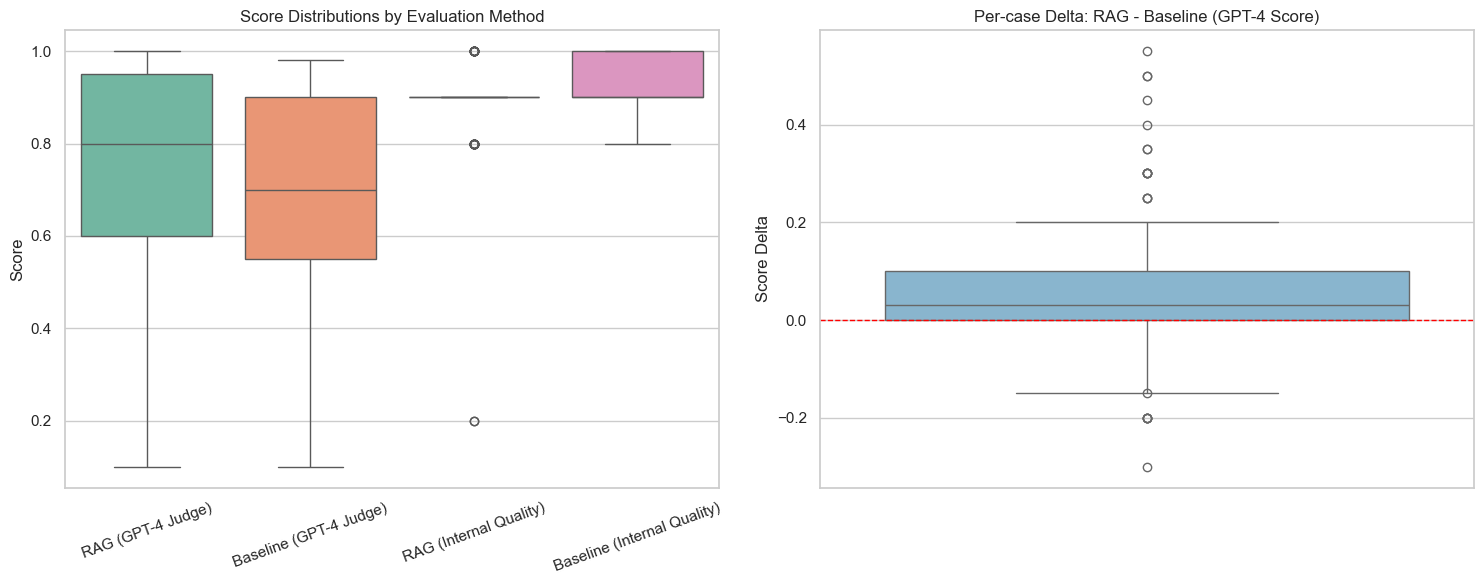

Saved box plot figure to: D:\Dev\masters\data\rag_baseline_score_boxplots.png


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Long format for boxplots across all methods.
plot_df = stats_df[
    [
        "rag_gpt4_score",
        "baseline_gpt4_score",
        "rag_internal_quality_score",
        "baseline_internal_quality_score",
    ]
].melt(var_name="method", value_name="score")

method_label_map = {
    "rag_gpt4_score": "RAG (GPT-4 Judge)",
    "baseline_gpt4_score": "Baseline (GPT-4 Judge)",
    "rag_internal_quality_score": "RAG (Internal Quality)",
    "baseline_internal_quality_score": "Baseline (Internal Quality)",
}
plot_df["method_label"] = plot_df["method"].map(method_label_map)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(
    data=plot_df,
    x="method_label",
    y="score",
    hue="method_label",
    ax=axes[0],
    palette="Set2",
    legend=False,
)
axes[0].set_title("Score Distributions by Evaluation Method")
axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=20)

# Distribution of per-case improvement from retrieval.
sns.boxplot(
    data=rag_vs_baseline_df,
    y="score_delta_rag_minus_baseline",
    ax=axes[1],
    color="#7db8da",
)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Per-case Delta: RAG - Baseline (GPT-4 Score)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Score Delta")

plt.tight_layout()
plt.show()

# Optional: save figure
fig_path = ROOT / "data" / "rag_baseline_score_boxplots.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Saved box plot figure to: {fig_path}")

## PDF report export

Writes `data/rag_vs_radiologist_analysis_report.pdf`: **page 1** = text summary (methods, key numeric results); **page 2** = box-plot figure. The file handle is closed when `PdfPages` exits so buffers are **flushed** to disk.

In [20]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.figure import Figure
from matplotlib import pyplot as plt
from matplotlib.image import imread


def _kappa_band(kappa: float) -> str:
    if pd.isna(kappa):
        return "undefined"
    if kappa < 0.0:
        return "less than chance"
    if kappa < 0.21:
        return "slight"
    if kappa < 0.41:
        return "fair"
    if kappa < 0.61:
        return "moderate"
    if kappa < 0.81:
        return "substantial"
    return "almost perfect"


pdf_path = ROOT / "data" / "rag_vs_radiologist_analysis_report.pdf"
png_path = ROOT / "data" / "rag_baseline_score_boxplots.png"

lines = [
    "RAG vs radiologist reference — analysis report",
    "",
    f"Paired sample size: n = {len(stats_df)}",
    "",
    "Friedman test (four related methods)",
    f"  chi-square = {friedman_stat:.6f}, p = {friedman_p:.6g}",
    f"  alpha = 0.05 -> {'reject null (methods differ overall)' if friedman_p < 0.05 else 'fail to reject null'}",
    "",
    "Pairwise Wilcoxon signed-rank + Bonferroni (k=6 comparisons)",
]
for _, r in pairwise_df.sort_values("p_bonferroni").iterrows():
    sig = "significant" if r["significant_after_bonferroni"] else "not significant"
    lines.append(
        f"  {r['method_a']} vs {r['method_b']}: p_bonf={r['p_bonferroni']:.4g} ({sig})"
    )

lines += ["", "Cohen kappa"]
for _, row in kappa_summary.iterrows():
    k = row["cohens_kappa"]
    lines.append(f"  {row['comparison']}: kappa = {k:.4f} ({_kappa_band(k)})")

mean_delta = rag_vs_baseline_df["score_delta_rag_minus_baseline"].mean()
lines += [
    "",
    "Mean per-case delta (RAG - baseline GPT-4 score)",
    f"  {mean_delta:.4f}",
    "",
    f"PASS_THRESHOLD for binary kappa: {PASS_THRESHOLD}",
]

max_lines_per_page = 40
line_chunks = [lines[i : i + max_lines_per_page] for i in range(0, len(lines), max_lines_per_page)]

with PdfPages(pdf_path) as pdf:
    for ti, chunk_lines in enumerate(line_chunks):
        chunk = "\n".join(chunk_lines)
        fig = Figure(figsize=(8.27, 11.69))
        ax = fig.add_subplot(111)
        ax.axis("off")
        title = f"Summary (part {ti + 1}/{len(line_chunks)})" if len(line_chunks) > 1 else "Summary"
        ax.text(0.05, 0.99, title, fontsize=10, fontweight="bold", va="top", ha="left")
        ax.text(0.05, 0.96, chunk, fontsize=7, va="top", ha="left", family="monospace")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

    if png_path.is_file():
        fig2 = Figure(figsize=(11, 6))
        ax2 = fig2.add_subplot(111)
        ax2.imshow(imread(str(png_path)))
        ax2.axis("off")
        ax2.set_title("Box plots (saved PNG)")
        pdf.savefig(fig2, bbox_inches="tight")
        plt.close(fig2)

print(f"PDF report written and flushed to: {pdf_path.resolve()}")

PDF report written and flushed to: D:\Dev\masters\data\rag_vs_radiologist_analysis_report.pdf
